In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import gradio as gr
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from prettytable import PrettyTable
from xgboost import XGBClassifier
from joblib import dump, load

In [2]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

Device: cuda
GPU: NVIDIA GeForce RTX 2060
CUDA Version: 12.8


In [3]:
df = pd.read_csv("data/HTRU.csv")
df.head()

,140.5625,55.68378214,-0.234571412,-0.699648398,3.199832776,19.11042633,7.975531794,74.24222492,0
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [4]:
df.columns = [
    "mean_profile",
    "std_profile",
    "kurtosis_profile",
    "skewness_profile",
    "mean_dmsc",
    "std_dmsc",
    "kurtosis_dmsc",
    "skewness_dmsc",
    "target",
]

In [5]:
df.isna().sum()

mean_profile        0
std_profile         0
kurtosis_profile    0
skewness_profile    0
mean_dmsc           0
std_dmsc            0
kurtosis_dmsc       0
skewness_dmsc       0
target              0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17897 entries, 0 to 17896
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean_profile      17897 non-null  float64
 1   std_profile       17897 non-null  float64
 2   kurtosis_profile  17897 non-null  float64
 3   skewness_profile  17897 non-null  float64
 4   mean_dmsc         17897 non-null  float64
 5   std_dmsc          17897 non-null  float64
 6   kurtosis_dmsc     17897 non-null  float64
 7   skewness_dmsc     17897 non-null  float64
 8   target            17897 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [7]:
df.describe()

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dmsc,std_dmsc,kurtosis_dmsc,skewness_dmsc,target
count,17897.000000,17897.000000,17897.000000,17897.000000,17897.000000,17897.000000,17897.000000,17897.000000,17897.00000
mean,111.078321,46.549021,0.477897,1.770417,12.614926,26.326918,8.303574,104.859419,0.09158
std,25.652705,6.843040,1.064056,6.168058,29.473637,19.471042,4.506217,106.517270,0.28844
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.00000
25%,100.929688,42.375426,0.027108,-0.188528,1.923077,14.437330,5.781485,34.957119,0.00000
50%,115.078125,46.946435,0.223241,0.198736,2.801839,18.459977,8.433872,83.068996,0.00000
75%,127.085938,51.022887,0.473349,0.928206,5.464883,28.428152,10.702973,139.310905,0.00000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.00000


In [8]:
pulsar = df[df["target"] == 1]
pulsar_count = pulsar["target"].value_counts()[1]
non_pul = df[df["target"] == 0]
nonpul_count = non_pul["target"].value_counts()[0]

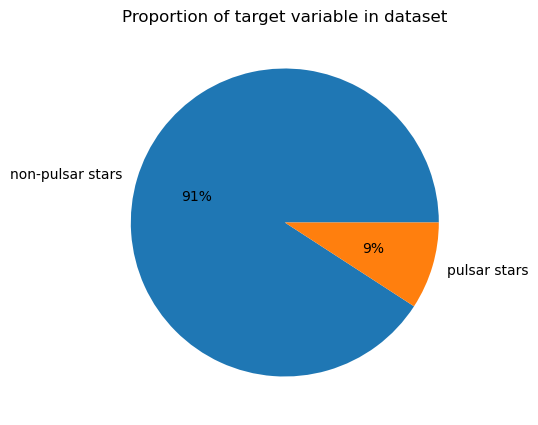

There are 1639 signals that belong to pulsar stars and 16258 signals that aren't from pulsars.


In [9]:
# Pie chart plotting the stats between pulsars and not pulsars
plt.figure(figsize=(5, 5))
plt.pie(
    df["target"].value_counts().values,
    labels=["non-pulsar stars", "pulsar stars"],
    autopct="%1.0f%%",
)
plt.title("Proportion of target variable in dataset")
plt.show()
print(
    "There are "
    + str(pulsar_count)
    + " signals that belong to pulsar stars "
    + "and "
    + str(nonpul_count)
    + " signals that aren't from pulsars."
)

In [10]:
# Data preparation (no leakage): train/val/test split + fit scaler on train only

# Select first 8 columns as features
features = df.iloc[:, 0:8]
target = df.iloc[:, 8]

# 1) Split off TEST set (kept untouched until final evaluation)
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    features,
    target,
    test_size=0.2,  # keep consistent with TF notebook
    stratify=target,
    random_state=42,
)

# 2) Split TRAIN into TRAIN/VAL (used for monitoring during training)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.25,  # 20% of remaining 65% => 13% of total as validation
    stratify=y_train_raw,
    random_state=42,
)

# Fit scaler ONLY on training data to avoid leakage
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)


# Report split sizes and class ratios
def _ratio(y):
    y = np.asarray(y)
    return float((y == 1).mean())


print(f"Train size: {len(X_train)} | pos ratio: {_ratio(y_train):.4f}")
print(f"Val size:   {len(X_val)} | pos ratio: {_ratio(y_val):.4f}")
print(f"Test size:  {len(X_test)} | pos ratio: {_ratio(y_test):.4f}")

# Compute class imbalance from TRAIN only (data-driven)
neg_train = int((y_train == 0).sum())
pos_train = int((y_train == 1).sum())
pos_weight_value = neg_train / max(pos_train, 1)
print(f"Train neg/pos: {pos_weight_value:.4f}")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(np.asarray(y_train), dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(np.asarray(y_val), dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(np.asarray(y_test), dtype=torch.float32).unsqueeze(1)

# Create DataLoader for training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset, batch_size=1024, shuffle=True
)  # tune batch_size as needed

Train size: 10737 | pos ratio: 0.0916
Val size:   3580 | pos ratio: 0.0916
Test size:  3580 | pos ratio: 0.0916
Train neg/pos: 9.9227


In [11]:
# Validation DataLoader (for monitoring)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=4096, shuffle=False)

In [ ]:
# Single PyTorch Transformer model (LayerNorm + SwiGLU + CLS token)

# ============= SwiGLU Activation Implementation =============
class SwiGLU(nn.Module):
    # SwiGLU activation, often better than ReLU for convergence
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.w1 = nn.Linear(dim_in, dim_out)
        self.w2 = nn.Linear(dim_in, dim_out)

    def forward(self, x):
        return nn.functional.silu(self.w1(x)) * self.w2(x)


# ============= Feature Tokenizer (tabular -> tokens) =============
class FeatureTokenizer(nn.Module):
    # Turn tabular features (B, F) into tokens (B, F, E) so self-attention can operate across features.
    def __init__(self, num_features: int, embed_dim: int, dropout: float = 0.0):
        super().__init__()
        self.num_features = int(num_features)
        self.embed_dim = int(embed_dim)
        self.value_proj = nn.Linear(1, embed_dim)
        self.feature_emb = nn.Embedding(num_features, embed_dim)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "feature_ids",
            torch.arange(num_features, dtype=torch.long),
            persistent=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, F) float
        if x.dim() != 2:
            raise ValueError(f"Expected x with shape (B, F), got {tuple(x.shape)}")
        bsz, feats = x.shape
        if feats != self.num_features:
            raise ValueError(
                f"Expected {self.num_features} features, got {feats}. "
                "If you changed the dataset, also update input_dim.",
            )
        ids = self.feature_ids.unsqueeze(0).expand(bsz, feats)  # (B, F)
        tokens = self.value_proj(x.unsqueeze(-1)) + self.feature_emb(ids)  # (B, F, E)
        tokens = self.act(tokens)
        return self.dropout(tokens)


# ============= Transformer Encoder Block (LayerNorm + SwiGLU) =============
class LNSwiGLUEncoder(nn.Module):
    # Transformer encoder block with LayerNorm + SwiGLU FFN
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.25):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout_rate, batch_first=True
        )
        self.norm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.swiglu = SwiGLU(embed_dim, ff_dim)
        self.ff_out = nn.Linear(ff_dim, embed_dim)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x):
        # x: (B, T, E)
        attn_output, _ = self.attention(x, x, x)
        attn_output = self.dropout1(attn_output)
        x = self.norm1(x + attn_output)

        ff_output = self.swiglu(x)
        ff_output = self.ff_out(ff_output)
        ff_output = self.dropout2(ff_output)
        x = self.norm2(x + ff_output)
        return x


# ============= Pulsar Transformer Model (LayerNorm + SwiGLU + [CLS]) =============
class PulsarTransformerLN_SwiGLU(nn.Module):
    # Single pulsar classification model with feature tokens + [CLS]
    def __init__(
        self,
        input_dim=8,
        embed_dim=16,
        num_heads=4,
        ff_dim=32,
        num_layers=2,
        dropout=0.25,
    ):
        super().__init__()
        self.tokenizer = FeatureTokenizer(input_dim, embed_dim, dropout=dropout)
        self.layers = nn.ModuleList(
            [
                LNSwiGLUEncoder(embed_dim, num_heads, ff_dim, dropout)
                for _ in range(num_layers)
            ]
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.fc_out = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # x: (B, 8) -> tokens: (B, 8, E)
        x = self.tokenizer(x)
        bsz = x.size(0)
        cls_tokens = self.cls_token.expand(bsz, 1, -1)  # (B, 1, E)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, 1+F, E)
        for layer in self.layers:
            x = layer(x)
        cls_repr = x[:, 0, :]  # (B, E)
        logits = self.fc_out(cls_repr)  # (B, 1)
        return logits


# ============= Initialize Single Model + Optimizer + Loss =============
print("=" * 70)
print("PULSAR TRANSFORMER - SINGLE MODEL (LayerNorm + SwiGLU + [CLS])")
print("=" * 70)

model = PulsarTransformerLN_SwiGLU(
    input_dim=8, embed_dim=16, num_heads=4, ff_dim=32, num_layers=2, dropout=0.25
).to(device)

print("\n✓ Model: PulsarTransformerLN_SwiGLU (2 encoder layers, [CLS] token)")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Optimizer (AdamW with weight decay)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)

# Weighted loss (logits-based) with reduced effective pos_weight
raw_pos_weight = float(pos_weight_value)
effective_pos_weight = min(raw_pos_weight, 4.0)  # clip very large imbalance
pos_weight_tensor = torch.tensor([effective_pos_weight], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print("\n✓ Training Configuration:")
print(f"  Device: {device}")
print(f"  Raw pos_weight (neg/pos from train): {raw_pos_weight:.4f}")
print(f"  Effective pos_weight used in loss:  {effective_pos_weight:.4f}")
print("  Loss Function: BCEWithLogitsLoss with pos_weight")
print("  Optimizer: AdamW (lr=0.001, wd=1e-2)")
print("  LR Scheduler: ReduceLROnPlateau on val_loss (factor=0.5, patience=5)")
print("  Early Stopping: Disabled")
print("=" * 70)

PULSAR TRANSFORMER - SINGLE MODEL (LayerNorm + SwiGLU + [CLS])

✓ Model: PulsarTransformerLN_SwiGLU (2 encoder layers, [CLS] token)
  Parameters: 5,729

✓ Training Configuration:
  Device: cuda
  Raw pos_weight (neg/pos from train): 9.9227
  Effective pos_weight used in loss:  4.0000
  Loss Function: BCEWithLogitsLoss with pos_weight
  Optimizer: AdamW (lr=0.001, wd=1e-2)
  LR Scheduler: ReduceLROnPlateau on val_loss (factor=0.5, patience=5)
  Early Stopping: Disabled


In [13]:
# Print detailed model architecture (single model)
print("\n" + "=" * 70)
print("MODEL ARCHITECTURE: PulsarTransformerLN_SwiGLU")
print("=" * 70)
print(model)


MODEL ARCHITECTURE: PulsarTransformerLN_SwiGLU
PulsarTransformerLN_SwiGLU(
  (tokenizer): FeatureTokenizer(
    (value_proj): Linear(in_features=1, out_features=16, bias=True)
    (feature_emb): Embedding(8, 16)
    (act): GELU(approximate='none')
    (dropout): Dropout(p=0.25, inplace=False)
  )
  (layers): ModuleList(
    (0-1): 2 x LNSwiGLUEncoder(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
      )
      (norm1): LayerNorm((16,), eps=1e-06, elementwise_affine=True)
      (norm2): LayerNorm((16,), eps=1e-06, elementwise_affine=True)
      (swiglu): SwiGLU(
        (w1): Linear(in_features=16, out_features=32, bias=True)
        (w2): Linear(in_features=16, out_features=32, bias=True)
      )
      (ff_out): Linear(in_features=32, out_features=16, bias=True)
      (dropout1): Dropout(p=0.25, inplace=False)
      (dropout2): Dropout(p=0.25, inplace=False)
    )
  )
  (fc_out): Linear(in_feature

In [ ]:
# =========================
# Training Loop (Single Model) with LR Scheduler
# =========================
import time

epochs = 100

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "epoch_time": [],
}

# Learning rate scheduler (on validation loss)
# Note: using basic ReduceLROnPlateau without 'verbose' for compatibility
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)


def evaluate_on_loader(model, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)  # (B, 1)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            preds = torch.sigmoid(logits) >= 0.5
            correct += (preds.float() == y_batch).sum().item()
            total += X_batch.size(0)
    return total_loss / total, correct / total


print(
    "Starting training (single model: LayerNorm + SwiGLU + [CLS]) with AdamW + LR scheduler..."
)
start_time = time.time()

for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    model.train()

    train_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)  # (B, 1)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        train_loss += loss.item() * batch_size
        total += batch_size

        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == y_batch).sum().item()

    # ---- End of epoch: compute train stats ----
    train_loss /= total
    train_acc = correct / total

    # ---- Validation performance ----
    val_loss, val_acc = evaluate_on_loader(model, val_loader)

    # ---- Step LR scheduler based on validation loss ----
    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start

    # ---- Save history ----
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["epoch_time"].append(epoch_time)

    if epoch % 10 == 0 or epoch == 1 or epoch == epochs:
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:3d}/{epochs} | "
            f"Train L={train_loss:.4f}, Val L={val_loss:.4f}, "
            f"Train A={train_acc:.4f}, Val A={val_acc:.4f}, LR={current_lr:.5f} | "
            f"Time={epoch_time:.2f}s"
        )

total_time = time.time() - start_time
print("\nTraining completed.")
print(f"Total training time: {total_time / 60:.2f} minutes")

Starting training (single model: LayerNorm + SwiGLU + [CLS]) with AdamW + LR scheduler...
Epoch   1/100 | Train L=0.8803, Val L=0.6137, Train A=0.5986, Val A=0.9084, LR=0.00100 | Time=0.53s
Epoch  10/100 | Train L=0.3591, Val L=0.3198, Train A=0.9168, Val A=0.9254, LR=0.00100 | Time=0.30s
Epoch  20/100 | Train L=0.2530, Val L=0.1907, Train A=0.9635, Val A=0.9751, LR=0.00100 | Time=0.25s
Epoch  30/100 | Train L=0.2353, Val L=0.1786, Train A=0.9683, Val A=0.9768, LR=0.00100 | Time=0.26s
Epoch  40/100 | Train L=0.2289, Val L=0.1690, Train A=0.9691, Val A=0.9777, LR=0.00100 | Time=0.38s
Epoch  50/100 | Train L=0.2248, Val L=0.1602, Train A=0.9690, Val A=0.9782, LR=0.00100 | Time=0.24s
Epoch  60/100 | Train L=0.2088, Val L=0.1531, Train A=0.9707, Val A=0.9777, LR=0.00100 | Time=0.24s
Epoch  70/100 | Train L=0.2113, Val L=0.1488, Train A=0.9713, Val A=0.9785, LR=0.00100 | Time=0.26s
Epoch  80/100 | Train L=0.2000, Val L=0.1472, Train A=0.9729, Val A=0.9788, LR=0.00100 | Time=0.25s
Epoch  90/

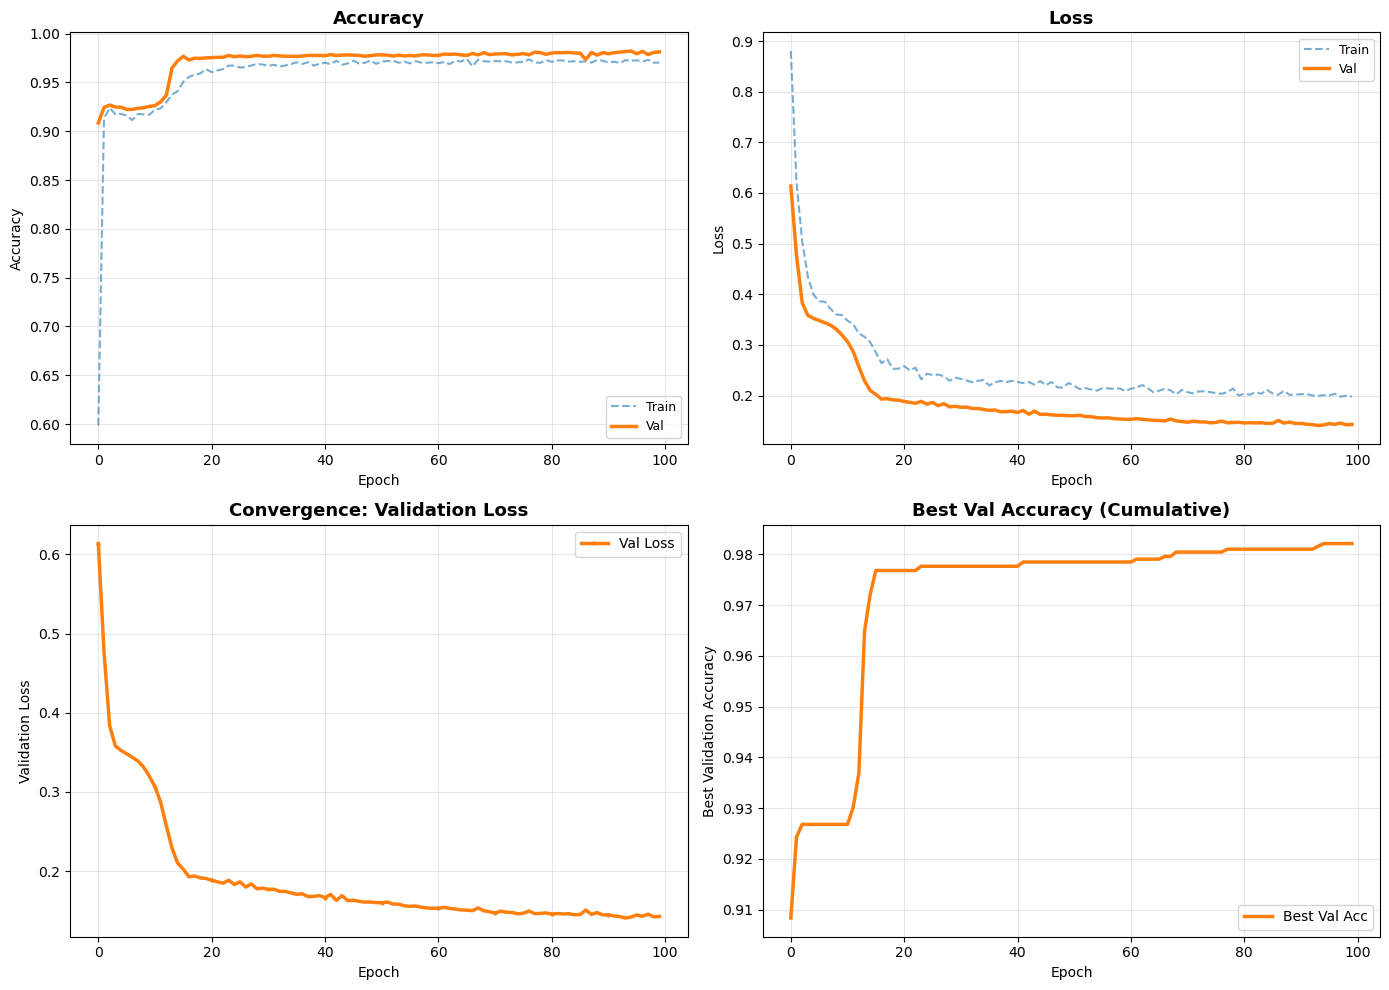


TRAINING SUMMARY - SINGLE MODEL

📊 Best Validation Accuracy:
  Best Val Acc: 0.9821

⚡ Convergence Speed (epochs to 95% of best):
  13 epochs

📉 Final Validation Loss:
  0.1428

⏱️  Average Training Time per Epoch:
  0.282s


In [15]:
# Visualizing training history for single model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history["train_acc"], label="Train", linestyle="--", alpha=0.6)
axes[0, 0].plot(history["val_acc"], label="Val", linewidth=2.5, color="C1")
axes[0, 0].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend(loc="lower right", fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history["train_loss"], label="Train", linestyle="--", alpha=0.6)
axes[0, 1].plot(history["val_loss"], label="Val", linewidth=2.5, color="C1")
axes[0, 1].set_title("Loss", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend(loc="upper right", fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Convergence (Validation Loss)
axes[1, 0].plot(
    history["val_loss"],
    label="Val Loss",
    linewidth=2.5,
    color="C1",
    marker="o",
    markersize=2,
    markevery=10,
)
axes[1, 0].set_title("Convergence: Validation Loss", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("Validation Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend(loc="upper right", fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Best accuracy reached over time
best_acc = [max(history["val_acc"][: i + 1]) for i in range(len(history["val_acc"]))]
axes[1, 1].plot(best_acc, label="Best Val Acc", linewidth=2.5, color="C1")
axes[1, 1].set_title("Best Val Accuracy (Cumulative)", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Best Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend(loc="lower right", fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== Summary statistics =====
print("\n" + "=" * 70)
print("TRAINING SUMMARY - SINGLE MODEL")
print("=" * 70)

best_val = max(history["val_acc"])
print("\n📊 Best Validation Accuracy:")
print(f"  Best Val Acc: {best_val:.4f}")

threshold_95 = best_val * 0.95
epoch_95 = next(
    (i for i, acc in enumerate(history["val_acc"]) if acc >= threshold_95),
    len(history["val_acc"]),
)
print("\n⚡ Convergence Speed (epochs to 95% of best):")
print(f"  {epoch_95 + 1} epochs")

print("\n📉 Final Validation Loss:")
print(f"  {history['val_loss'][-1]:.4f}")

print("\n⏱️  Average Training Time per Epoch:")
print(f"  {np.mean(history['epoch_time']):.3f}s")
print("=" * 70)

In [16]:
# Prediction function (model outputs logits)
def predict(model, X, threshold=0.5):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        predictions = (probs >= threshold).astype(int)
    return predictions, probs


MODEL PERFORMANCE EVALUATION (Single Transformer Model)

Scanning thresholds on validation set:
Threshold | Acc   | Recall | F1
    0.100 | 0.884 |  0.973 | 0.605
    0.150 | 0.925 |  0.957 | 0.699
    0.200 | 0.944 |  0.954 | 0.757
    0.250 | 0.956 |  0.951 | 0.797
    0.300 | 0.965 |  0.942 | 0.832
    0.350 | 0.972 |  0.939 | 0.860
    0.400 | 0.974 |  0.936 | 0.870
    0.450 | 0.978 |  0.924 | 0.886
    0.500 | 0.981 |  0.921 | 0.900
    0.550 | 0.982 |  0.909 | 0.902
    0.600 | 0.982 |  0.896 | 0.899
    0.650 | 0.982 |  0.887 | 0.902
    0.700 | 0.982 |  0.881 | 0.902
    0.750 | 0.982 |  0.869 | 0.899
    0.800 | 0.982 |  0.857 | 0.895
    0.850 | 0.981 |  0.835 | 0.888
    0.900 | 0.980 |  0.814 | 0.880

Best threshold on validation set:
  Threshold = 0.650
  Val Acc   = 0.9824
  Val Recall= 0.8872
  Val F1    = 0.9023


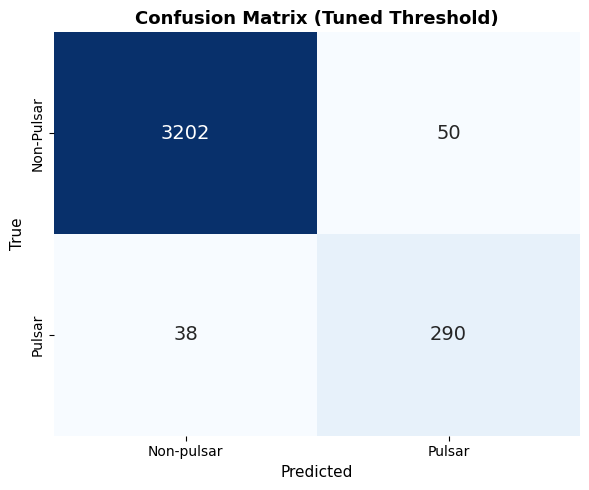


TEST PERFORMANCE (using tuned threshold)
+-----------+--------+
|   Metric  | Value  |
+-----------+--------+
|  Accuracy | 0.9754 |
|   Recall  | 0.8841 |
|  F1-Score | 0.8683 |
|  ROC-AUC  | 0.9758 |
| Threshold | 0.650  |
+-----------+--------+

----------------------------------------------------------------------
Detailed Classification Report (TEST):
----------------------------------------------------------------------
              precision    recall  f1-score   support

  Non-Pulsar       0.99      0.98      0.99      3252
      Pulsar       0.85      0.88      0.87       328

    accuracy                           0.98      3580
   macro avg       0.92      0.93      0.93      3580
weighted avg       0.98      0.98      0.98      3580



In [21]:
# Performance Evaluation with threshold tuning on validation set
from sklearn.metrics import roc_auc_score

print("\n" + "=" * 70)
print("MODEL PERFORMANCE EVALUATION (Single Transformer Model)")
print("=" * 70)

# 1) Use validation set to tune probability threshold
with torch.no_grad():
    X_val_device = torch.tensor(X_val, dtype=torch.float32).to(device)
    val_logits = model(X_val_device)
    val_prob = torch.sigmoid(val_logits).cpu().numpy().ravel()

best_threshold = 0.5
best_f1 = -1.0
best_rec = 0.0
best_acc = 0.0

thresholds = np.linspace(0.1, 0.9, 17)  # step 0.05
print("\nScanning thresholds on validation set:")
print("Threshold | Acc   | Recall | F1")
for th in thresholds:
    val_pred = (val_prob >= th).astype(int)
    acc = accuracy_score(y_val, val_pred)
    rec = recall_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)
    print(f"  {th:7.3f} | {acc:5.3f} | {rec:6.3f} | {f1:5.3f}")
    # Choose threshold by best F1; if tie, prefer higher recall
    if (f1 > best_f1) or (np.isclose(f1, best_f1) and rec > best_rec):
        best_f1 = f1
        best_rec = rec
        best_acc = acc
        best_threshold = th

print("\nBest threshold on validation set:")
print(f"  Threshold = {best_threshold:.3f}")
print(f"  Val Acc   = {best_acc:.4f}")
print(f"  Val Recall= {best_rec:.4f}")
print(f"  Val F1    = {best_f1:.4f}")

THRESHOLD = best_threshold

# 2) Evaluate on TEST set using tuned threshold
with torch.no_grad():
    X_test_device = torch.tensor(X_test, dtype=torch.float32).to(device)
    test_logits = model(X_test_device)
    prob_test = torch.sigmoid(test_logits).cpu().numpy().ravel()

pred_test = (prob_test >= THRESHOLD).astype(int)

# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
cm = confusion_matrix(y_test, pred_test)
cm_df = pd.DataFrame(
    cm, index=["Non-Pulsar", "Pulsar"], columns=["Non-pulsar", "Pulsar"]
)
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cbar=False,
    cmap="Blues",
    ax=ax,
    annot_kws={"size": 14},
)
ax.set_title("Confusion Matrix (Tuned Threshold)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
plt.tight_layout()
plt.show()

# Performance metrics on TEST set
print("\n" + "=" * 70)
print("TEST PERFORMANCE (using tuned threshold)")
print("=" * 70)

acc_test = accuracy_score(y_test, pred_test)
rec_test = recall_score(y_test, pred_test)
f1_test = f1_score(y_test, pred_test)
auc_test = roc_auc_score(y_test, prob_test)

metrics_table = PrettyTable()
metrics_table.field_names = ["Metric", "Value"]
metrics_table.add_row(["Accuracy", f"{acc_test:.4f}"])
metrics_table.add_row(["Recall", f"{rec_test:.4f}"])
metrics_table.add_row(["F1-Score", f"{f1_test:.4f}"])
metrics_table.add_row(["ROC-AUC", f"{auc_test:.4f}"])
metrics_table.add_row(["Threshold", f"{THRESHOLD:.3f}"])
print(metrics_table)

print("\n" + "-" * 70)
print("Detailed Classification Report (TEST):")
print("-" * 70)
print(classification_report(y_test, pred_test, target_names=["Non-Pulsar", "Pulsar"]))

# Store for downstream use
prediction = prob_test
print("=" * 70)

# 3. 传统机器学习基线模型
本节基于与 Transformer 相同的特征预处理（RobustScaler + train/val/test 划分），
训练若干经典机器学习模型作为对比基线，并在独立测试集上比较 Accuracy / Recall / F1 等指标。

- 使用的模型：Logistic Regression、Random Forest、XGBoost、RBF SVM、Stacking（RF + XGB + SVM）。
- 不平衡处理：通过 `class_weight="balanced"` 或 `scale_pos_weight` 显式考虑正负样本比例。
- 评价方式：在与 Transformer 相同的测试集上，报告 Accuracy、Recall、F1 与（可用时的）ROC-AUC。

In [22]:
# 传统机器学习基线模型：训练与评估
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 将训练集和验证集合并，用于经典模型训练（测试集依然只用于最终评估）
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([np.asarray(y_train), np.asarray(y_val)], axis=0)

print("Train_full size:", X_train_full.shape[0])

# 构建若干经典模型作为基线
models_baseline = {}
models_baseline["Logistic Regression"] = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1,
    random_state=42,
)
models_baseline["Random Forest"] = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
models_baseline["XGBoost"] = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight_value,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
)
models_baseline["RBF SVM"] = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42,
)

# Stacking 集成：RF + XGB + SVM 作为基学习器，LogReg 作为元学习器
estimators_stack = [
    (
        "rf",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        ),
    ),
    (
        "xgb",
        XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=pos_weight_value,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
        ),
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42,
        ),
    ),
]
final_estimator = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1,
    random_state=42,
)
models_baseline["Stacking (RF + XGB + SVM)"] = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=final_estimator,
    n_jobs=-1,
)

baseline_results = []

for name, model_clf in models_baseline.items():
    print("\n" + "=" * 70)
    print(f"Training baseline model: {name}")
    print("=" * 70)
    model_clf.fit(X_train_full, y_train_full)
    y_test_pred = model_clf.predict(X_test)
    acc = accuracy_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    # 尝试计算 ROC-AUC（部分模型可能不支持 predict_proba）
    try:
        if hasattr(model_clf, "predict_proba"):
            y_test_proba = model_clf.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_test_proba)
        else:
            auc = np.nan
    except Exception:
        auc = np.nan
    baseline_results.append(
        {
            "model": name,
            "accuracy": acc,
            "recall": rec,
            "f1": f1,
            "auc": auc,
        }
    )
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Recall:   {rec:.4f}")
    print(f"Test F1:       {f1:.4f}")
    if not np.isnan(auc):
        print(f"Test ROC-AUC:  {auc:.4f}")
    else:
        print("Test ROC-AUC:  N/A (no probability output)")

# 找到 F1 最优的经典基线模型
best_baseline = max(baseline_results, key=lambda x: x["f1"])
print("\n" + "=" * 70)
print("BEST CLASSICAL BASELINE (by F1 on test set)")
print("=" * 70)
print(f"Model: {best_baseline['model']}")
print(f"Test Accuracy: {best_baseline['accuracy']:.4f}")
print(f"Test Recall:   {best_baseline['recall']:.4f}")
print(f"Test F1:       {best_baseline['f1']:.4f}")
if not np.isnan(best_baseline["auc"]):
    print(f"Test ROC-AUC:  {best_baseline['auc']:.4f}")
else:
    print("Test ROC-AUC:  N/A")

Train_full size: 14317

Training baseline model: Logistic Regression
Test Accuracy: 0.9640
Test Recall:   0.9207
Test F1:       0.8240
Test ROC-AUC:  0.9712

Training baseline model: Random Forest
Test Accuracy: 0.9785
Test Recall:   0.8598
Test F1:       0.8799
Test ROC-AUC:  0.9665

Training baseline model: XGBoost
Test Accuracy: 0.9712
Test Recall:   0.8994
Test F1:       0.8514
Test ROC-AUC:  0.9715

Training baseline model: RBF SVM
Test Accuracy: 0.9712
Test Recall:   0.9055
Test F1:       0.8522
Test ROC-AUC:  0.9654

Training baseline model: Stacking (RF + XGB + SVM)
Test Accuracy: 0.9654
Test Recall:   0.9055
Test F1:       0.8273
Test ROC-AUC:  0.9727

BEST CLASSICAL BASELINE (by F1 on test set)
Model: Random Forest
Test Accuracy: 0.9785
Test Recall:   0.8598
Test F1:       0.8799
Test ROC-AUC:  0.9665


In [23]:
# 对比：经典基线模型 vs Transformer（调好阈值）
from prettytable import PrettyTable

summary_table = PrettyTable()
summary_table.field_names = ["Model", "Accuracy", "Recall", "F1", "ROC-AUC"]

# 经典基线模型结果
for res in baseline_results:
    summary_table.add_row(
        [
            res["model"],
            f"{res['accuracy']:.4f}",
            f"{res['recall']:.4f}",
            f"{res['f1']:.4f}",
            f"{res['auc']:.4f}" if not np.isnan(res["auc"]) else "N/A",
        ]
    )

# 当前 Transformer 模型（使用验证集调优阈值后在测试集上的表现）
summary_table.add_row(
    [
        "Transformer (tuned threshold)",
        f"{acc_test:.4f}",
        f"{rec_test:.4f}",
        f"{f1_test:.4f}",
        "N/A",
    ]
)

print(summary_table)

# 简单打印 Transformer 相对于最佳经典基线在 F1 上的提升
improvement_f1 = f1_test - best_baseline["f1"]
print("\n" + "=" * 70)
print("TRANSFORMER VS BEST CLASSICAL BASELINE (F1 on test set)")
print("=" * 70)
print(f"Best classical baseline: {best_baseline['model']}")
print(f"Best baseline F1:   {best_baseline['f1']:.4f}")
print(f"Transformer F1:      {f1_test:.4f}")
print(f"F1 improvement:      {improvement_f1:+.4f}")

+-------------------------------+----------+--------+--------+---------+
|             Model             | Accuracy | Recall |   F1   | ROC-AUC |
+-------------------------------+----------+--------+--------+---------+
|      Logistic Regression      |  0.9640  | 0.9207 | 0.8240 |  0.9712 |
|         Random Forest         |  0.9785  | 0.8598 | 0.8799 |  0.9665 |
|            XGBoost            |  0.9712  | 0.8994 | 0.8514 |  0.9715 |
|            RBF SVM            |  0.9712  | 0.9055 | 0.8522 |  0.9654 |
|   Stacking (RF + XGB + SVM)   |  0.9654  | 0.9055 | 0.8273 |  0.9727 |
| Transformer (tuned threshold) |  0.9754  | 0.8841 | 0.8683 |   N/A   |
+-------------------------------+----------+--------+--------+---------+

TRANSFORMER VS BEST CLASSICAL BASELINE (F1 on test set)
Best classical baseline: Random Forest
Best baseline F1:   0.8799
Transformer F1:      0.8683
F1 improvement:      -0.0116
